In [1]:
# Imports
import duckdb
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
DATABASE_PATH = "../../database/eBuS.duckdb"
OUTPUT_PATH = Path(r"C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots")
VEHICLE_DICT = {"Ebusco2.2electric12m": "Ebusco 2.2", "SolarsisUrbino12electric": "Urbino 12", "SolarsisUrbino18electric": "Urbino 18"}

   timestep_time vehicle_id  vehicle_actualBatteryCapacity  \
0            0.0   bus_1051                      239554.80   
1           60.0   bus_1051                      240659.57   
2          120.0   bus_1051                      243034.57   
3          180.0   bus_1051                      245409.57   
4          240.0   bus_1051                      246439.06   

   vehicle_maximumBatteryCapacity scenario  seed  
0                        300000.0   summer    65  
1                        300000.0   summer    65  
2                        300000.0   summer    65  
3                        300000.0   summer    65  
4                        300000.0   summer    65  


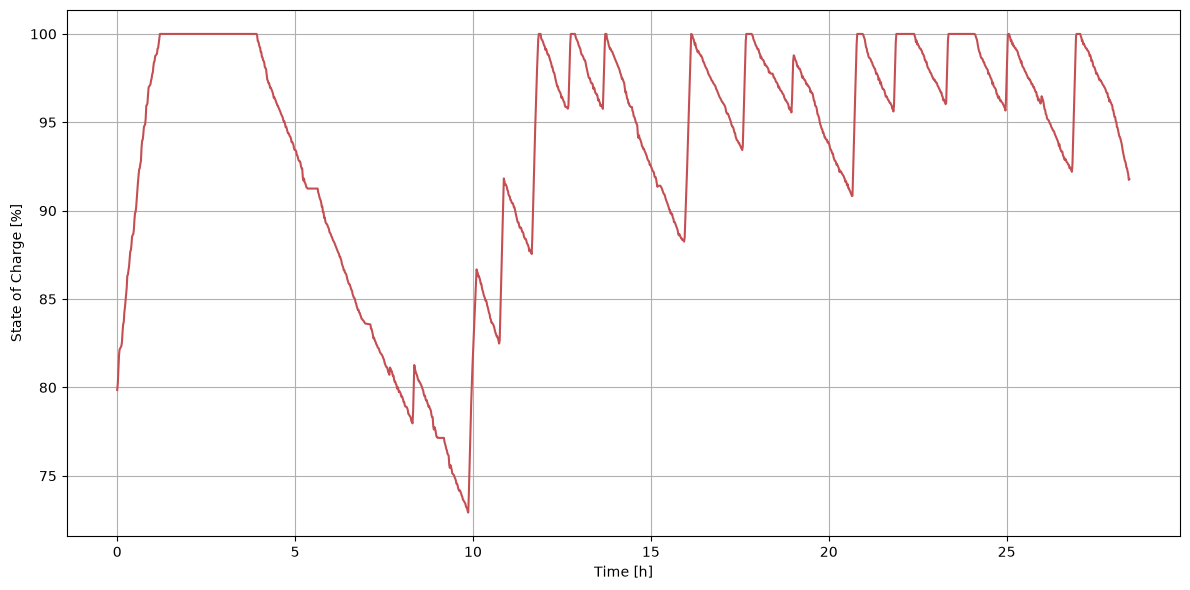

Saved: C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots\soc_over_time_1051.pdf


In [3]:
# 1051 Validation - State of Charge over Time
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        timestep_time, 
        vehicle_id, 
        vehicle_actualBatteryCapacity,
        vehicle_maximumBatteryCapacity,
        scenario, 
        seed, 
    FROM multirun_battery_aggregated
    WHERE scenario = 'summer' AND seed = 65 AND vehicle_id = 'bus_1051'
""").fetchdf()
con.close()

print(df.head())

df["soc"] = df["vehicle_actualBatteryCapacity"] / df["vehicle_maximumBatteryCapacity"] * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df["timestep_time"] / 3600,  # Convert seconds to hours
    df["soc"],
    color=PALETTE[3],
)

ax.set_xlabel("Time [h]")
ax.set_ylabel("State of Charge [%]")
ax.grid(True)

fig.tight_layout()

fig.savefig(
    OUTPUT_PATH / "soc_over_time_1051.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Saved: {OUTPUT_PATH / 'soc_over_time_1051.pdf'}")

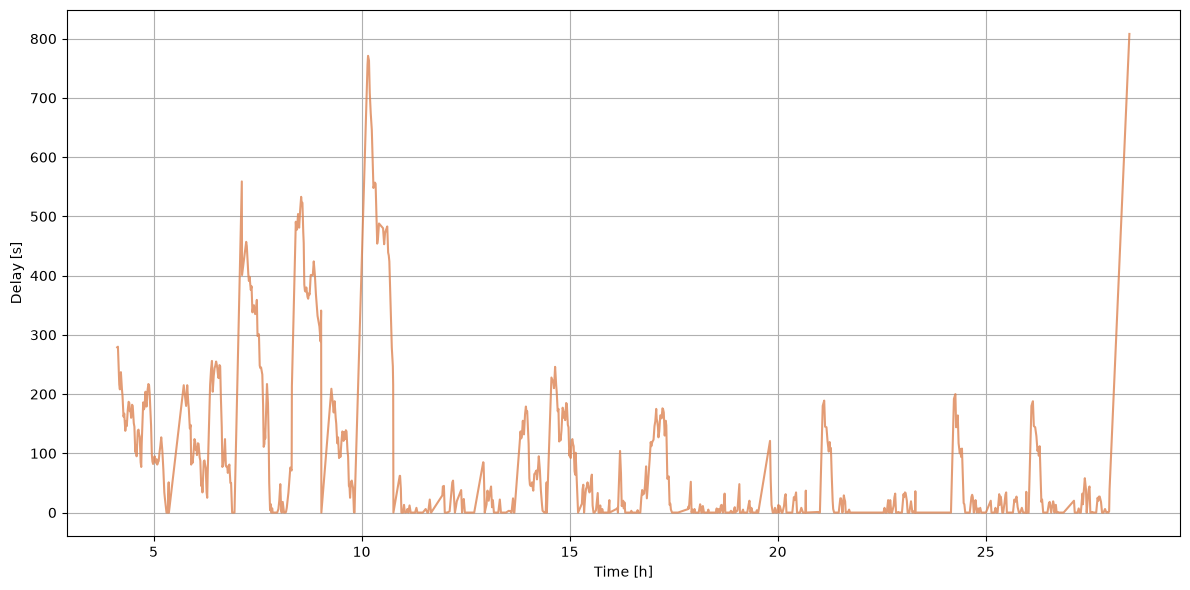

Saved: C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots\delay_over_time_1051.pdf


In [4]:
# 1051 Validation - Delay over Time
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        stopinfo_delay,
        stopinfo_started, 
        stopinfo_id, 
        scenario, 
        seed, 
    FROM multirun_stopinfo
    WHERE scenario = 'summer' AND seed = 65 AND stopinfo_id = 'bus_1051'
""").fetchdf()
con.close()

# Drop leading rows with stopinfo_delay == 0, up to the first non-zero value
nonzero_idx = df.index[df["stopinfo_delay"] != 0]
if len(nonzero_idx) > 0:
    df = df.loc[nonzero_idx[0]:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df["stopinfo_started"] / 3600,  # Convert seconds to hours
    df["stopinfo_delay"],
    #linestyle=":",
    alpha=0.8,
    color=PALETTE[1],
)
"""
ax.scatter(
    df["stopinfo_started"] / 3600,  # Convert seconds to hours
    df["stopinfo_delay"],
    color=PALETTE[0],
)"""
ax.set_xlabel("Time [h]")
ax.set_ylabel("Delay [s]")
ax.grid(True)

fig.tight_layout()

fig.savefig(
    OUTPUT_PATH / "delay_over_time_1051.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Saved: {OUTPUT_PATH / 'delay_over_time_1051.pdf'}")


Energy efficiency statistics — SUMMER

Vehicle type: Ebusco 2.2
----------------------------------------
count        76.000000
mean     570215.191977
std       50693.520255
min      440204.431101
25%      547339.032959
50%      580485.471734
75%      601917.101620
max      680853.827514

Vehicle type: Urbino 12
----------------------------------------
count        49.000000
mean     615153.562789
std       58886.958623
min      461150.936054
25%      592691.079507
50%      618439.258586
75%      639277.409264
max      728966.819064

Vehicle type: Urbino 18
----------------------------------------
count    2.640000e+02
mean     9.976032e+05
std      9.028788e+04
min      7.021603e+05
25%      9.451004e+05
50%      1.000279e+06
75%      1.061533e+06
max      1.263494e+06


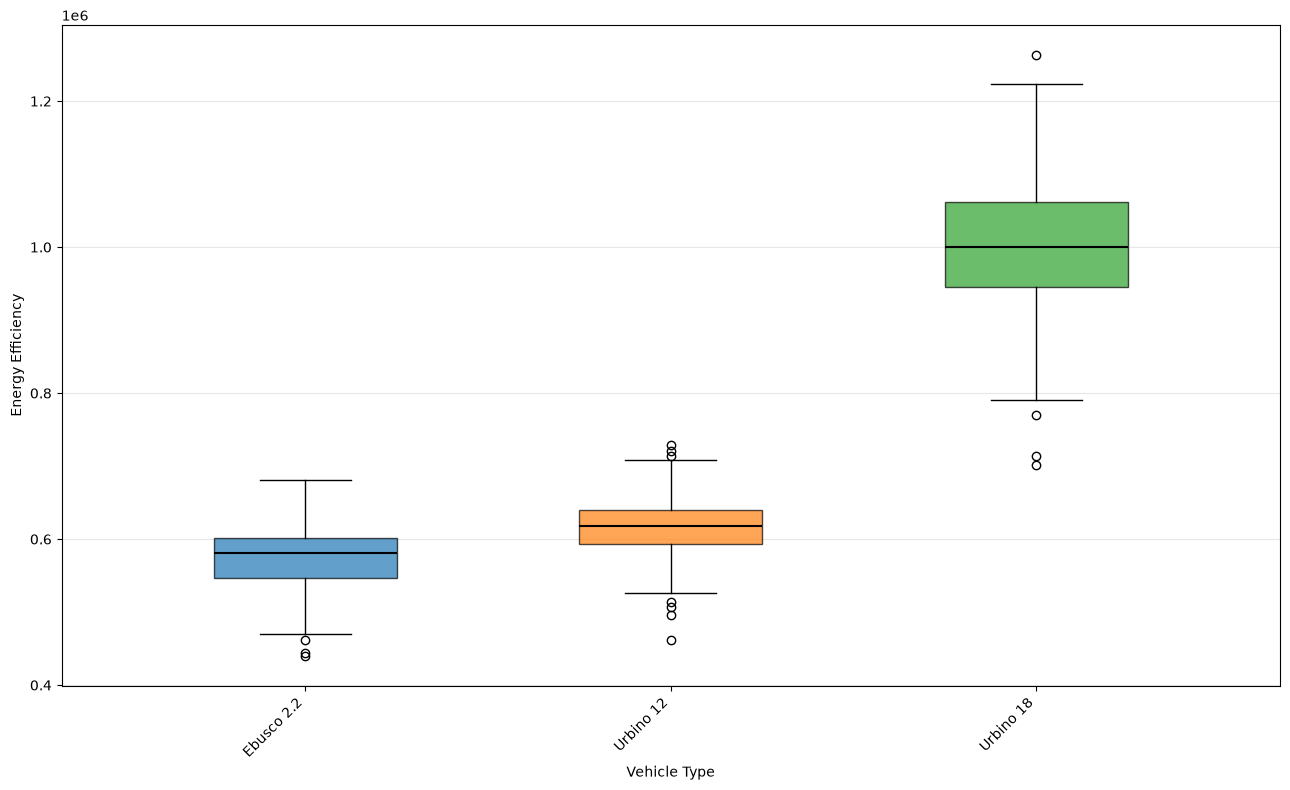


Saved: C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots\energy_efficiency_summer.pdf

Energy efficiency statistics — WINTER

Vehicle type: Ebusco 2.2
----------------------------------------
count        76.000000
mean     607659.925742
std       52730.779633
min      471657.293783
25%      582220.472121
50%      618149.473479
75%      641795.834461
max      724514.050289

Vehicle type: Urbino 12
----------------------------------------
count        49.000000
mean     656021.038093
std       61628.634124
min      494608.539168
25%      629045.512640
50%      658044.728310
75%      680238.201587
max      775295.971576

Vehicle type: Urbino 18
----------------------------------------
count    2.640000e+02
mean     1.025866e+06
std      9.216400e+04
min      7.287609e+05
25%      9.711542e+05
50%      1.026944e+06
75%      1.088953e+06
max      1.297270e+06


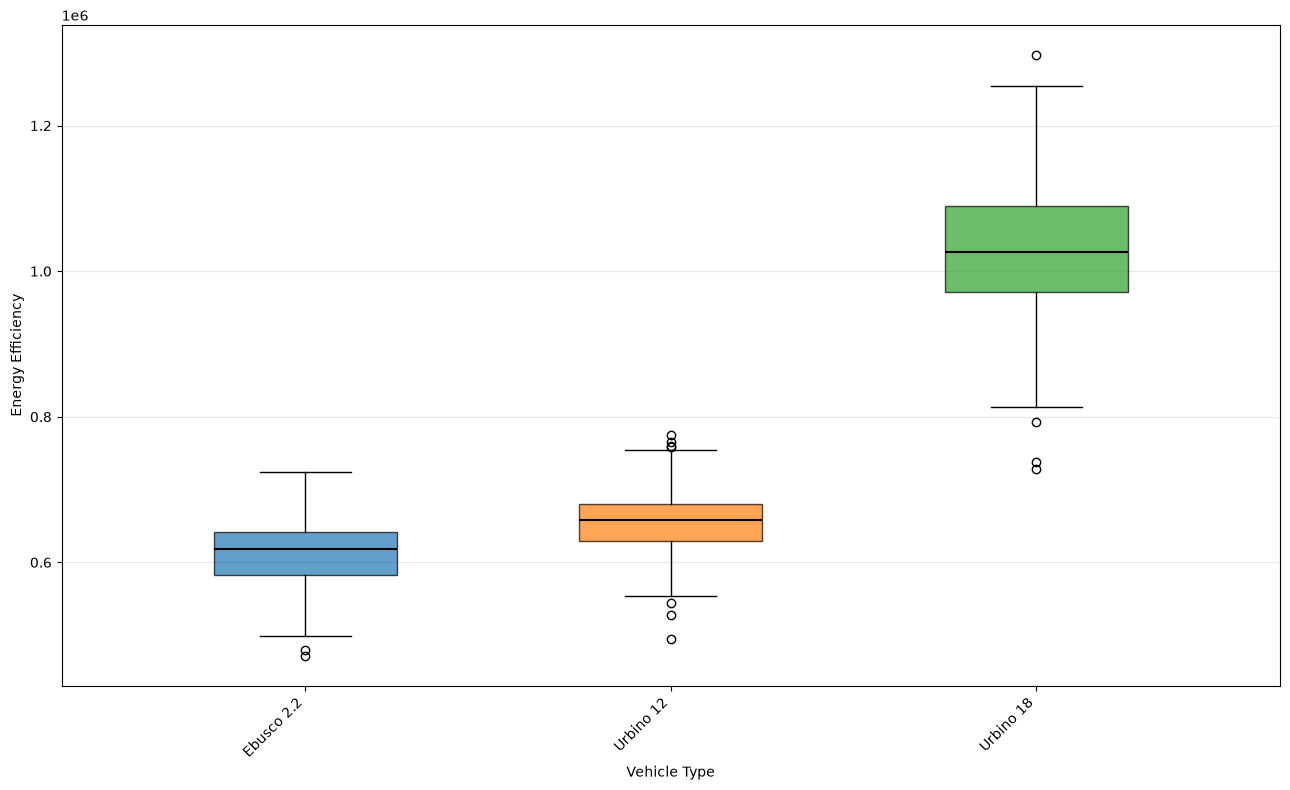


Saved: C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots\energy_efficiency_winter.pdf


In [7]:
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        tripinfo_id,
        battery_totalEnergyConsumed,
        battery_totalEnergyRegenerated, 
        tripinfo_routeLength,
        tripinfo_vType,
        scenario,
        seed
    FROM multirun_tripinfo
    WHERE scenario IN ('summer', 'winter')
    AND seed = 65
""").fetchdf()

con.close()

# Energy consumed per distance
df["energy_efficiency"] = (
    df["battery_totalEnergyConsumed"]-df["battery_totalEnergyRegenerated"] / df["tripinfo_routeLength"]
)

for scenario in ["summer", "winter"]:

    fig, ax = plt.subplots(figsize=(13, 8))

    subset = df[df["scenario"] == scenario].copy()

    # Keep vehicle types in a consistent order
    vtypes = sorted(subset["tripinfo_vType"].dropna().unique())

    # Data for each vehicle type
    boxplot_data = [
        subset.loc[
            subset["tripinfo_vType"] == vtype,
            "energy_efficiency"
        ].dropna()
        for vtype in vtypes
    ]

    positions = np.arange(1, len(vtypes) + 1) * 0.3

    # Create boxplots side-by-side
    bp = ax.boxplot(
        boxplot_data,
        positions=positions,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5)
    )

    # Different color for each vehicle type
    cmap = plt.get_cmap("tab10")

    for i, box in enumerate(bp["boxes"]):
        box.set_facecolor(cmap(i % 10))
        box.set_alpha(0.7)


    ax.set_xticks(positions)
    ax.set_xticklabels(
        [VEHICLE_DICT.get(vtype, vtype) for vtype in vtypes],
        rotation=45,
        ha="right"
    )

    ax.set_xlim(
        positions[0] - 0.2,
        positions[-1] + 0.2
    )

    ax.set_xlabel("Vehicle Type")
    ax.set_ylabel("Energy Efficiency")

    ax.grid(axis="y", alpha=0.3)

    # ---------------------------------------------------------
    # Print statistics
    # ---------------------------------------------------------

    print("\n" + "=" * 70)
    print(f"Energy efficiency statistics — {scenario.upper()}")
    print("=" * 70)

    for vtype in vtypes:
        values = subset.loc[
            subset["tripinfo_vType"] == vtype,
            "energy_efficiency"
        ].dropna()

        print(f"\nVehicle type: {VEHICLE_DICT.get(vtype)}")
        print("-" * 40)
        print(values.describe().to_string())

    # ---------------------------------------------------------
    # Save figure
    # ---------------------------------------------------------

    fig.tight_layout()

    output_file = OUTPUT_PATH / f"energy_efficiency_{scenario}.pdf"

    fig.savefig(
        output_file,
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"\nSaved: {output_file}")